In [1]:
import numpy as np
import jax
import jaxlib
import jax.numpy as jnp
import flax
import flax.linen as nn
import optax
from typing import Tuple, Callable, Any, Dict, Optional
import numpy.typing as npt
import copy
import pathlib
import matplotlib.pyplot as plt
import time
import json
import ast
import netket as nk
import os
import glob
import sys
sys.path.append("/home/ihuarte/Escritorio/Ivan/NNs")

#os.chdir("/home/ihuarte/Escritorio/Ivan/NN/")

# from ATMOS_VA.VA_project.src.VA_project.model.model import OxalateJKGamma
# from ATMOS_VA.VA_project.src.VA_project.engine.runners import Runner

#from NN_utils import load_vstate
#from correlations import correlations_vstate

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
print(jax.devices())

from NN_module.ST_utils import compare_params, masked_optimizer



[CudaDevice(id=0)]


In [5]:
from VA_project.initialize_model import ModelFactory
import json
with open('config_CM.json', 'r') as f:
    config = json.load(f)


In [6]:
size = config['sizes'][0]
factory = ModelFactory(size, config)


In [7]:
for params in factory.get_params():
    print(params)
    print(factory.params)
    print('\n')

{'J1': 1.0, 'J2': 0.5, 'fields': [[0.0, 0.0, 0.0]]}
{'J1': 1.0, 'J2': 0.5, 'fields': [[0.0, 0.0, 0.0]]}


{'J1': 1.0, 'J2': 1.0, 'fields': [[0.0, 0.0, 0.0]]}
{'J1': 1.0, 'J2': 1.0, 'fields': [[0.0, 0.0, 0.0]]}


{'J1': 1.0, 'J2': 1.5, 'fields': [[0.0, 0.0, 0.0]]}
{'J1': 1.0, 'J2': 1.5, 'fields': [[0.0, 0.0, 0.0]]}




[100] ['M'] 0.01
[100] ['P'] 0.1
[100]
[3000] ['B', 'M'] 0.0005
[3000]
[200] ['M'] 1e-06
[200]
[200] ['P'] 0.05
[200]


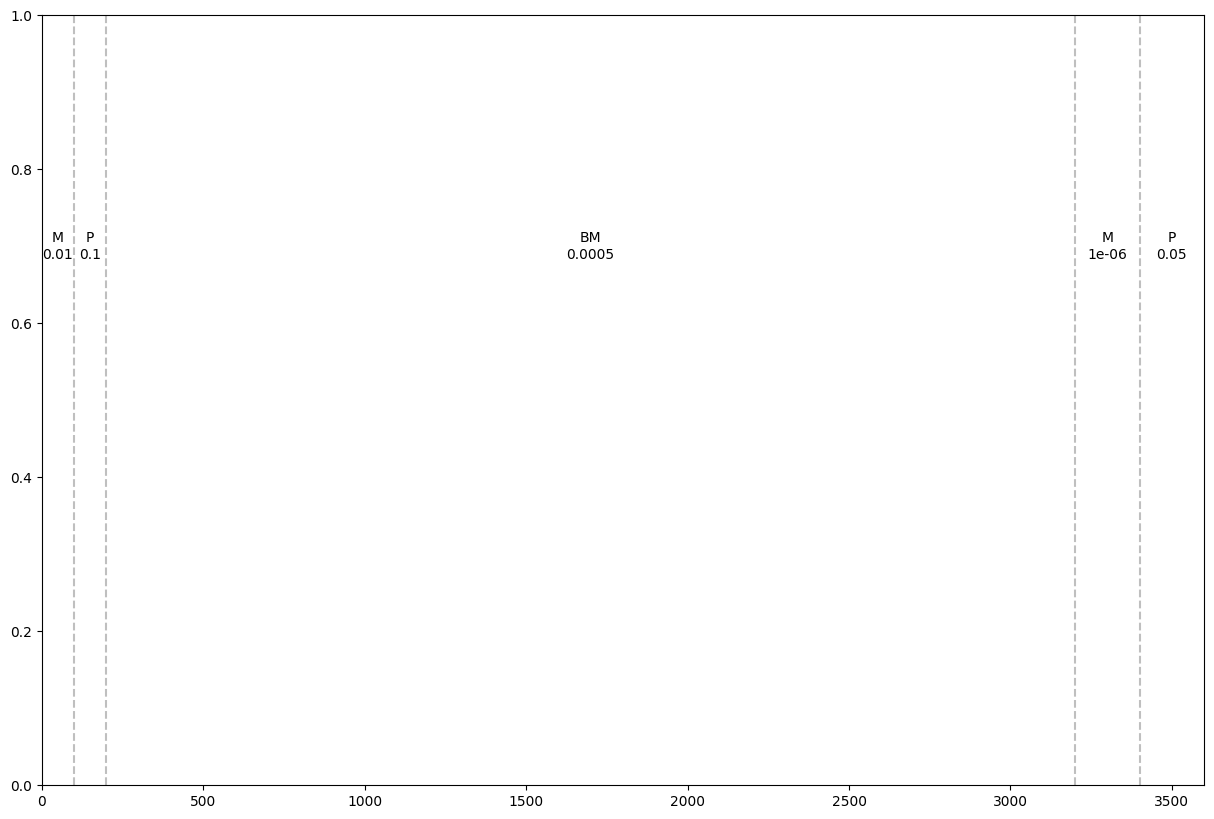

In [22]:
segments = []
modes = []
lr_schedule = []
s, m, r, lr_sch = (
    setup["segments"],
    setup["mode"],
    setup["repeat_segment"],
    setup["lr_schedule_setup"]
)

for seg, mode, repeats, lrsch in zip(s, m, r, lr_sch):
    segments += [seg] * repeats
    modes += [mode] * repeats
    lr_schedule += [lrsch] * repeats

total_segments = len(segments)
total_epochs = int(np.array([s for seg in segments for s in seg]).sum())




fig, ax = plt.subplots(figsize=[15,10])
ax.set_xlim(0, total_epochs)
cum_epoch = 0
for i, (segment, seg_modes, lr) in enumerate(
    zip(segments, modes, lr_schedule)
):
    print(segment, seg_modes, lr)

    if i != 0:
        ax.axvline(cum_epoch, color="grey", linestyle="--", alpha=0.5)
        print(segment)
    
    ax.text(
        cum_epoch + segment[0]/2, 0.7, f"{''.join(seg_modes)}\n{lr}",
        horizontalalignment="center", verticalalignment="center",
        fontsize=10, color="black"
        )

    cum_epoch += segment[0]

In [15]:
print(f"Segments:\n{segments}")
print(f"Modes:\n{modes}")
print(f"LR schedule:\n{lr_schedule}")

Segments:
[[100], [100], [3000], [200], [200]]
Modes:
[['M'], ['P'], ['B'], ['M'], ['P']]
LR schedule:
[0.01, 0.1, 0.0005, 1e-06, 0.05]


Configurations:
 - /home/ihuarte/Escritorio/Ivan/NNs/config.json
 - /home/ihuarte/Escritorio/Ivan/NNs/config_CM.json
 - /home/ihuarte/Escritorio/Ivan/NNs/config_NN.json
Total samples: 1024


──────────────────────────── 🧲 CM: J1J2Square   🧠 NN_architecture: Parallel_Marshall ────────────────────────────

🧱 Size: 4x4

╭────────────────────────────────────────────────── J1J2Square ───────────────────────────────────────────────────╮
│ J1= 1.0  J2= 0.5  fields= [0.0, 0.0, 0.0]  size= [4, 4]                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── Parallel_Marshall ───────────────────────────────────────────────╮
│ module= SplitTraining  setup= {'modulus_setup': {'module': 'CvT', 'setup': {'n_CP_blocks': [2],                 │
│                        'channels': [32], 'attn_heads': [4], 'kernel': [3, 3], 'final_architecture': [64,        │
│                        5]}}, 'phase_setup': {'module': 'Transversal', 'setup': {'Trans_0': {'module':           │
│                        'CvT', 'setup': {'n_CP_blocks': [2], 'channels': [32], 'attn_heads': [4],                │
│                        'kernel': [3, 3], 'final_architecture': [64, 5]}}, 'Trans_1': {'module':                 │
│                        'MarshallSign', 'setup': {'radians': True}}}}, 'symm_Z2': True, 'trivial_Z2':            │
│                        True, 'symm_2D': False, 'squeeze': True}                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

────────────────────────────────────────────────────────  ─────────────────────────────────────────────────────────

Running exact diagonalization...
Energy ED: -7.66557607921719


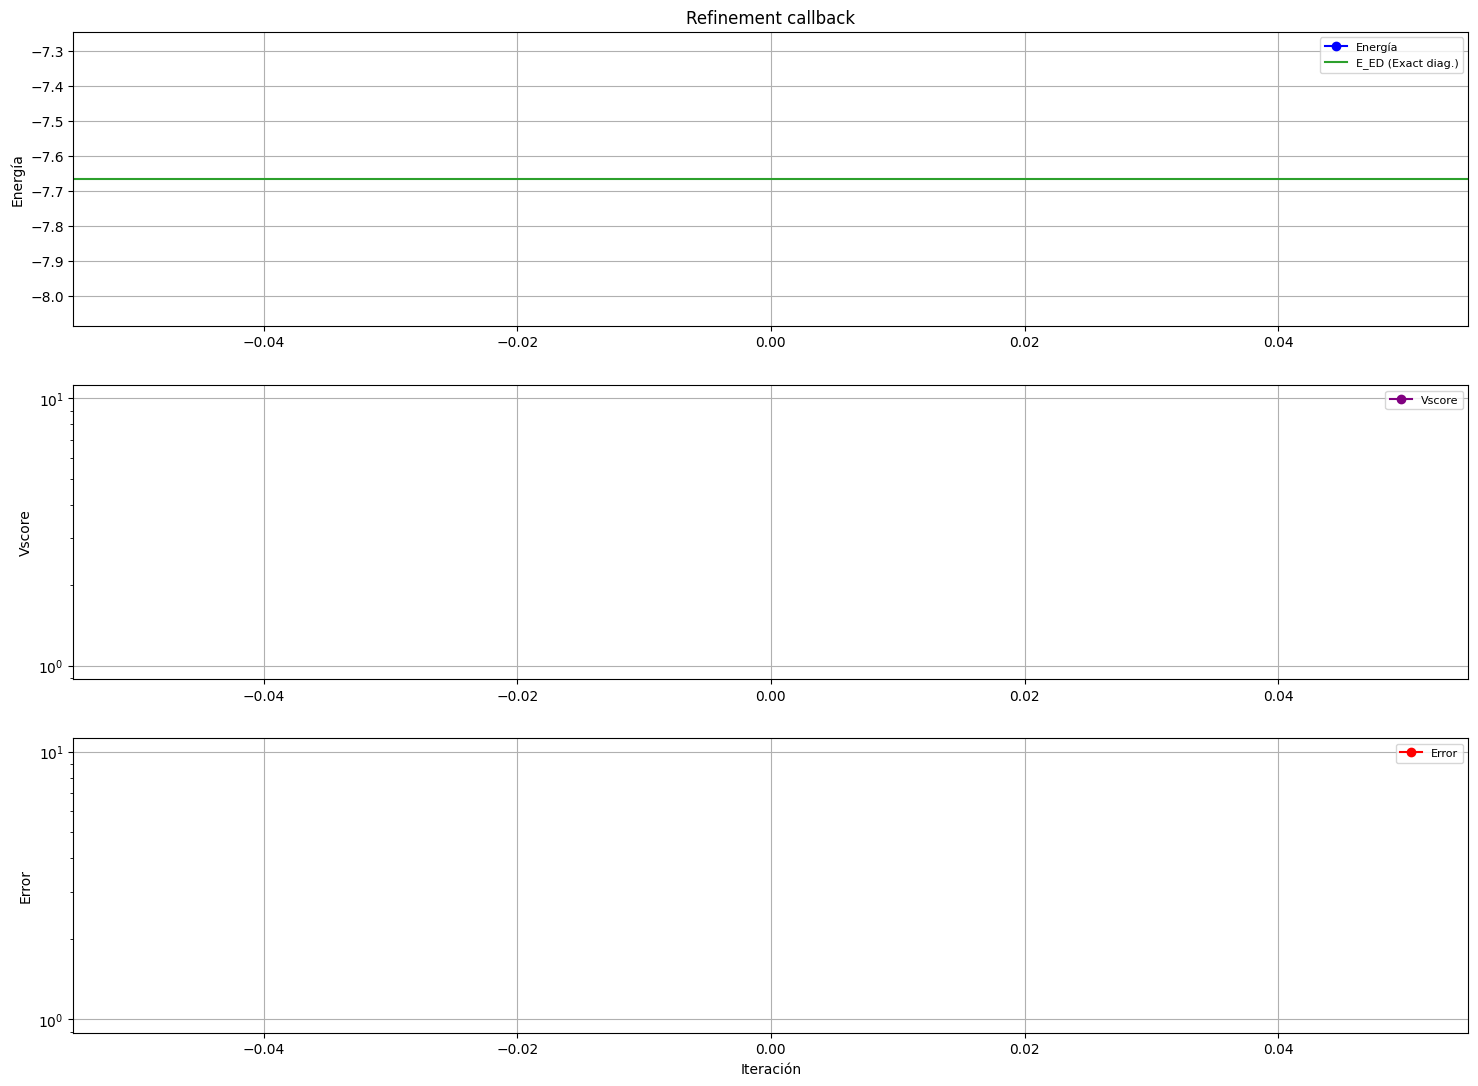

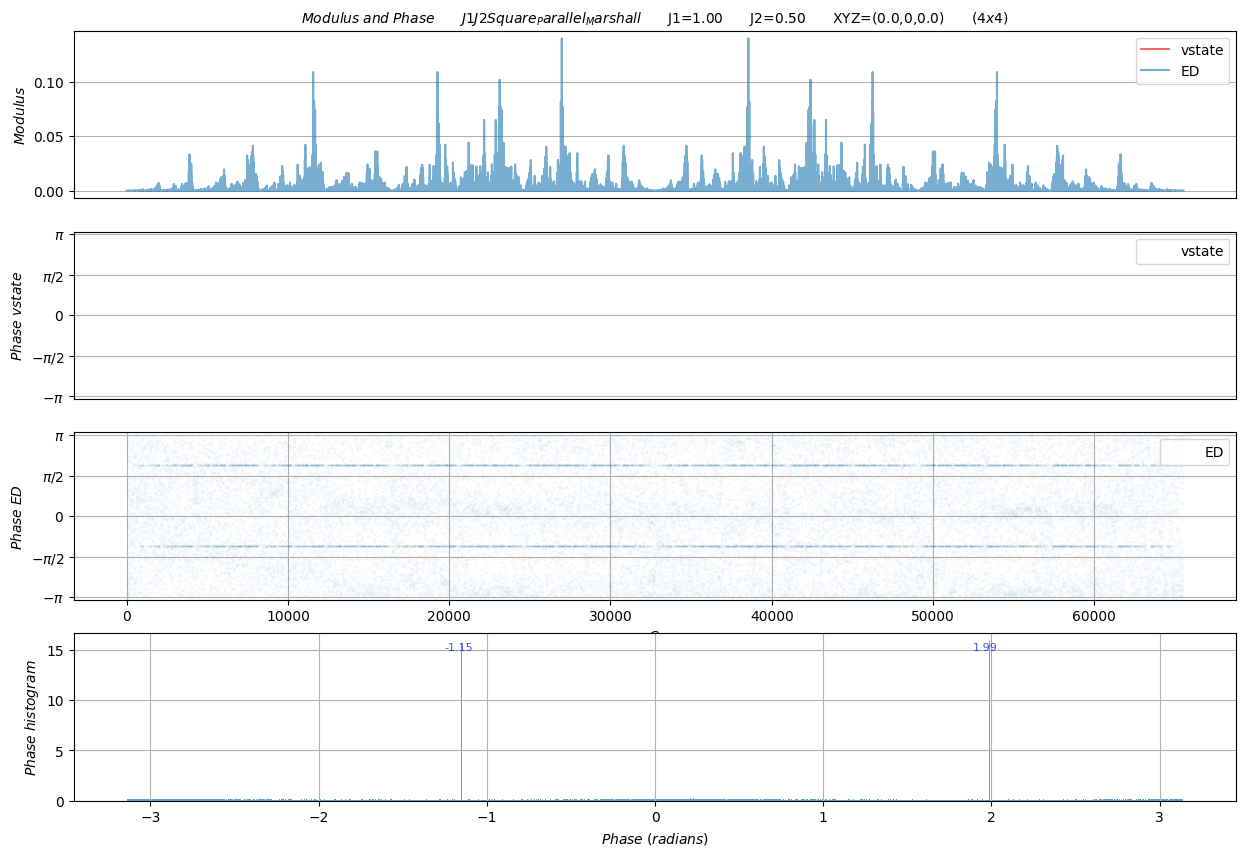


Epochs:      2800
Segments:      [[100], [100], [100], [100], [1000], [100], [100], [1000], [100], [100]]
Modes:         [['M'], ['P'], ['M'], ['P'], ['B'], ['M'], ['P'], ['B'], ['M'], ['P']]

Segment 1 of 10......   lr: 0.0100  ds: 0.0100



In [1]:
%run ./SplitTraining_J1J2.py

In [2]:
states=hi.all_states()
N=hi.size

bin_states=(-(states-1)/2).astype(jnp.int8)
bin_states = bin_states.T[::-1].T
powers = jnp.tile(jnp.arange(N), (bin_states.shape[0],1))

idx = jnp.sum(bin_states * 2**powers, axis=-1)

idx

Array([    0,     1,     2, ..., 65533, 65534, 65535], dtype=int64)

In [ ]:

N = vstate.hilbert.size
samples = vstate.samples.reshape(-1,N)
bin_samples = (-(samples-1)/2).astype(jnp.int8)
bin_samples = bin_samples.T[::-1].T
powers = jnp.tile(jnp.arange(N), (bin_samples.shape[0],1))
samples_idx = jnp.sum(bin_samples * 2**powers, axis=-1)


In [7]:
a=jnp.ones((3,4,8))

jnp.mean(a, axis=0).shape

(4, 8)

In [3]:
x = jnp.ones((1,16))
variables = model.init(jax.random.PRNGKey(0), x)
def collect_paths(tree, prefix=()):
    paths = []
    for k, v in tree.items():
        if isinstance(v, dict):
            paths.extend(collect_paths(v, prefix + (k,)))
        else:
            paths.append(prefix + (k,))
    return paths

# El árbol de parámetros (por ejemplo, 'params' de variables de Flax)
from flax.core import unfreeze
paths = collect_paths(unfreeze(variables['params']))

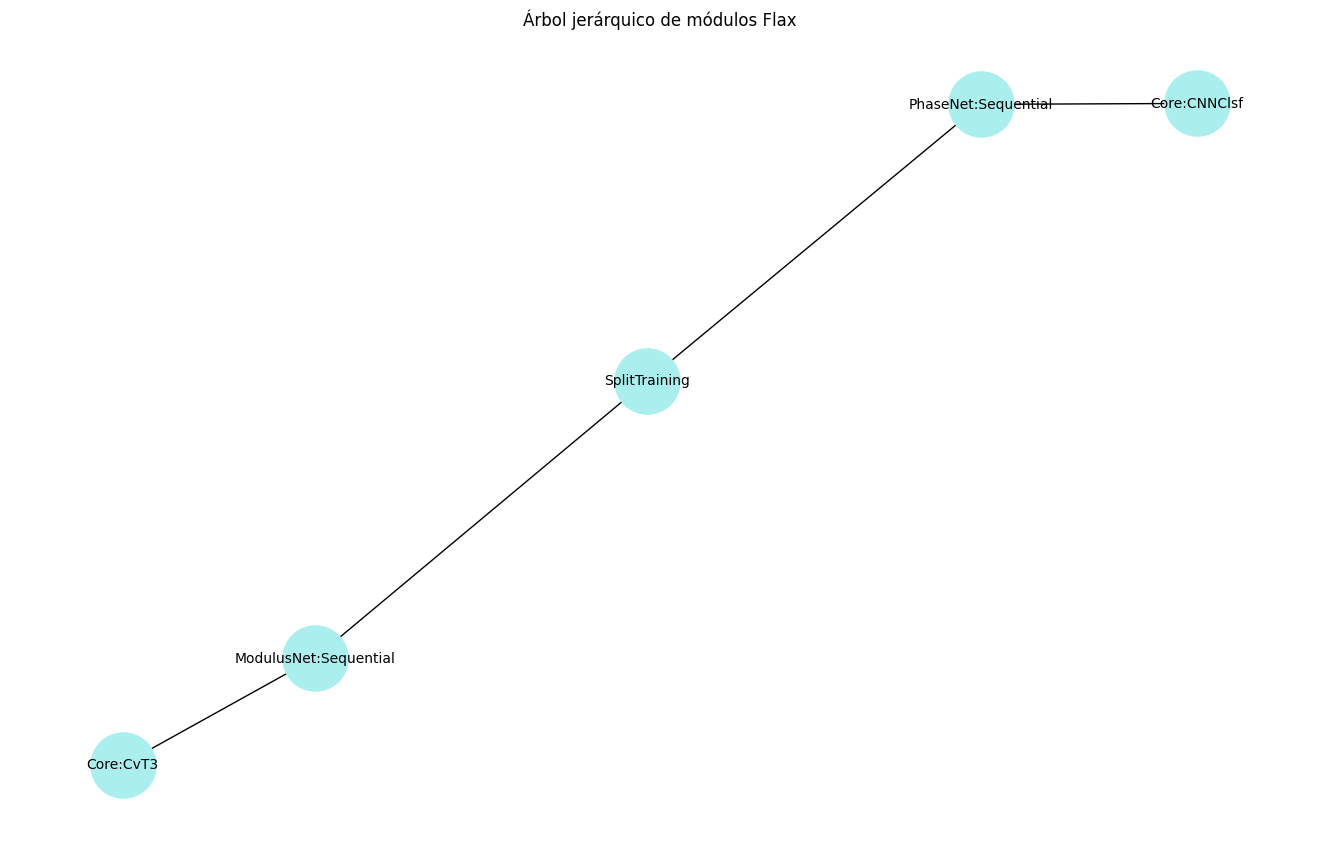

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

from typing import Any

def build_flax_tree_graph(module: nn.Module, parent=None, graph=None):
    """
    Recorre los atributos tipo nn.Module y construye un árbol jerárquico.
    El nombre de cada nodo es 'Campo:Clase'.
    """
    if graph is None:
        graph = nx.DiGraph()
        root = type(module).__name__
        graph.add_node(root)
        parent = root

    for field in module.__dataclass_fields__:
        submod = getattr(module, field)
        if isinstance(submod, nn.Module):
            child_name = f"{field}:{type(submod).__name__}"
            graph.add_node(child_name)
            graph.add_edge(parent, child_name)
            build_flax_tree_graph(submod, parent=child_name, graph=graph)
        # Si el atributo es None, omitimos
    return graph

def plot_flax_tree(graph):
    # Usa layout jerárquico si tienes pydot y graphviz instalados, 
    # sino, usa un layout de fallback que sigue el orden topológico:
    try:
        pos = nx.nx_pydot.graphviz_layout(graph, prog='dot')
    except Exception:
        pos = nx.spring_layout(graph, seed=42)
    plt.figure(figsize=(13, 8))
    nx.draw(graph, pos, with_labels=True, node_size=2200, node_color="#aee", font_size=10, arrows=False)
    plt.title("Árbol jerárquico de módulos Flax")
    plt.show()

tree = build_flax_tree_graph(model)
plot_flax_tree(tree)

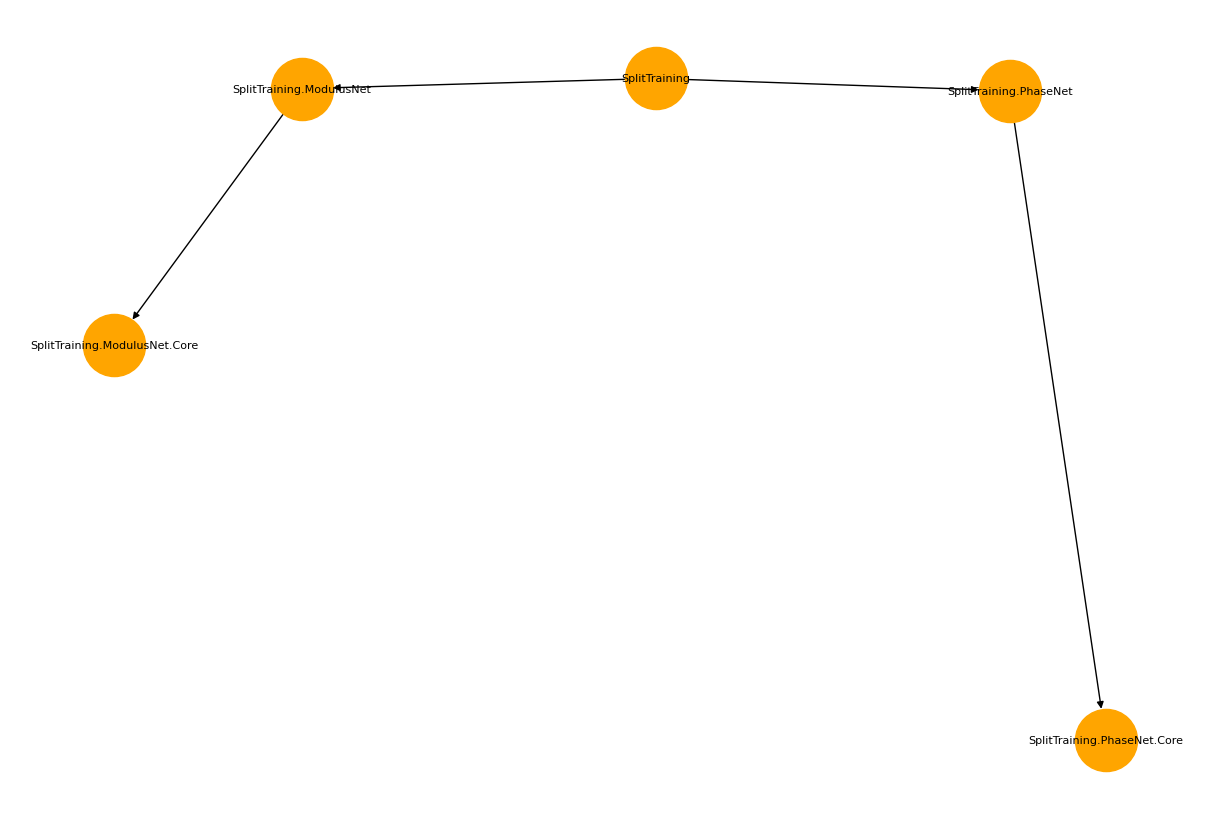

In [5]:
def add_module_nodes(G, mod, parent_name):
    for field in mod.__dataclass_fields__:
        val = getattr(mod, field)
        if isinstance(val, nn.Module):
            child_name = parent_name + "." + field
            G.add_edge(parent_name, child_name)
            add_module_nodes(G, val, child_name)

G = nx.DiGraph()
root_name = type(model).__name__
G.add_node(root_name)
add_module_nodes(G, model, root_name)

plt.figure(figsize=(12,8))
nx.draw(G, with_labels=True, node_size=2000, font_size=8, node_color="orange")
plt.show()

In [ ]:
from NN_module.NN_utils import modphase
import itertools

def all_spin_configurations(N):
    # Genera todas las combinaciones posibles de N spines con valores ±1
    return jnp.array(list(itertools.product([-1, 1], repeat=N)))

def print_max_contributors(x, size, N_max=10):
    (mod, ph), _ = modphase(x)
    configs = all_spin_configurations(size[0]*size[1])

    idx = jnp.argsort(mod)[::-1][:N_max]
    max_configs = configs[idx,:]
    max_mods = mod[idx]
    max_phs = ph[idx]


    for config, mod, phs in zip(max_configs, max_mods, max_phs):
        print(f"Config: \n{config.reshape(size)}")
        print(f"\nModulus: {mod}")
        print(f"Phase: {phs}\n")


In [ ]:
print_max_contributors(x_ED, size=(4,4), N_max=20)

In [ ]:
ize=(4,4)
N_max=5
(mod, ph), _ = modphase(x_ED)
configs = all_spin_configurations(size[0]*size[1])

idx = jnp.argsort(mod)[::-N_max]
max_configs = configs[idx,:]
max_mods = mod[idx]
max_phs = ph[idx]

In [ ]:
idx = jnp.argsort(mod)[::-N_max]

In [ ]:
def logpsi(p, s):
    return apply_fun({"params": p}, s)

params = vstate.parameters
apply_fun = vstate._apply_fun
s_batch = vstate.samples.reshape(-1, vstate.hilbert.size)
s_batch = jnp.asarray(s_batch, dtype=jnp.complex128)
grad_logpsi = jax.grad(lambda p, s: logpsi(p, s), holomorphic=True)

#y, Jt = jax.vjp(lambda p, s: logpsi(p, s),params,s_batch)

grads = jax.vmap(lambda s: grad_logpsi(params, s))(s_batch)

In [ ]:
Jt(y)

In [ ]:
P0 = vs_0.parameters
P1 = vs_1.parameters

G0 = jax.vmap(lambda s: grad_logpsi(P0, s))(s_batch)
G1 = jax.vmap(lambda s: grad_logpsi(P1, s))(s_batch)

compare_params(G0, G1, atol=1e-20)

In [ ]:
transformations = {
    "train": optax.sgd(0.1),
    "freeze": optax.set_to_zero(),
}

grad_trans, tree_mask = masked_optimizer(P0, transformations, 'modulus')


In [ ]:
nk.jax.tree_cast()

In [ ]:
a = np.array([0, np.pi])
a.std()

In [ ]:
def energy(params, vstate):
    return vstate.expect(H).mean.real
grads = jax.grad(energy)(vstate.parameters, vstate)

In [ ]:
grads

In [ ]:
import sys
from pathlib import Path
sys.path.append(Path().resolve().parent.parent / "ATMOS_VA/VA_project/src")
from VA_project.model.model import J1J2Square
from VA_project.model.cm import HeisenbergXYZ
from VA_project.engine.runners import Runner

from NN_module.NN_utils import modphase

size=(4,4)
fields=[0.0,0.0,0.0]
kwargs_lattice={'bc':'periodic', 'order':'default_2'}
J1_list=np.linspace(-1,1,5)
J2_list=np.linspace(-1,1,5)

for J1 in J1_list:
    for J2 in J2_list:
        if J1==0.0 and J2==0.0:
            continue
        j1j2 = J1J2Square(size, J1, J2, fields, **kwargs_lattice)
        eng=Runner(j1j2.cm, S_operators=True)
        E_lanc = eng.exact_energy_lanczos(k = 100, eigenstates=False)

        fig, ax = plt.subplots()
        ax.set_title(f"J1-J2 model   J1:{J1}  J2:{J2}   size:{size[0]}x{size[1]}")
        ax.plot(range(len(E_lanc)), np.sort(E_lanc), marker='o', ms=1.2, color='r', label='Energy')
        ax.set_xlabel("Sorted eigenvalues")
        ax.set_ylabel(f"Energy")
        ax.grid()
        plt.tight_layout()
        plt.savefig(f"/home/ihuarte/Escritorio/Ivan/NNs/J1J2Spectra/Spctra_size_{size[0]}x{size[1]}_J1_{J1}_J2_{J2}.png",  dpi=600, bbox_inches="tight")


In [ ]:
idx = np.argsort(E_lanc)
E_lanc, x_lanc = E_lanc.T[idx][:e], x_lanc.T[:e]
#x_lanc = np.where(x_lanc>1e-13,x_lanc,0.0)
E_lanc, x_lanc 

In [ ]:
eig = np.linalg.eigh(H)
E_ed, x_ed = eig.eigenvalues[0:e],eig.eigenvectors.T[0:e]
E_ed, x_ed.shape

In [ ]:
mod_lanc = []
phase_lanc = []
mod_ed = []
phase_ed = []
stats_lanc = []
stats_ed = []
for x_E, x_L in zip(x_ed, x_lanc):
    assert len(x_E)==len(x_L)
    (mod_L, phase_L), stats_L = modphase(x_L)
    (mod_E, phase_E), stats_E = modphase(x_E)
    
    mod_lanc.append(mod_L)
    phase_lanc.append(mod_L)
    mod_ed.append(mod_E)
    phase_ed.append(phase_E)

    stats_lanc.append(stats_L)
    stats_ed.append(stats_E)




In [ ]:
title=r"J1:\;%.1f\quad J2:\;%.1f\qquad(%dx%d)"%(J1,J2,size[0],size[1])

In [ ]:
ms = 3

for mod_L, phase_L, stats_L, mod_E, phase_E, stats_E in zip(mod_lanc, phase_lanc, stats_lanc, mod_ed, phase_ed, stats_ed):
    fig,ax= plt.subplots(4,1, figsize=[20,15])

    ax[0].set_title(r"$Modulus\;and\;Phase\qquad %s$"%(title), fontsize=10)
    ax[0].set_xticks([])
    ax[0].set_ylabel(r"$Modulus$")
    ax[0].set_ylim(-0.00001,max(max(mod_E),max(mod_L))*9/8)
    ax[0].plot(mod_L, alpha=0.6, color='r', label=f"Lanczos")
    ax[0].plot(mod_E, alpha=0.6, label= f"ED")
    ax[0].legend()

    ax[1].set_xticks([])
    ax[1].set_yticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
    ax[1].set_yticklabels([r"$-\pi$",r"$-\pi/2$",r"$0$",r"$\pi/2$",r"$\pi$"])
    ax[1].set_ylabel(r"$Phase \;ED$")
    ax[1].set_ylim(-np.pi-0.1, np.pi+0.1)
    ax[1].plot(phase_E, alpha=0.15, ls='', marker='o', ms=ms, color='r', label='ED')
    ax[1].legend(loc='upper right')

    ax[2].set_xlabel(r"$C_i$")
    ax[2].set_ylabel(r"$Phase \;Lanczos$")
    ax[2].set_ylim(-np.pi-0.1, np.pi+0.1)
    ax[2].set_yticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
    ax[2].set_yticklabels([r"$-\pi$",r"$-\pi/2$",r"$0$",r"$\pi/2$",r"$\pi$"])
    ax[2].plot(phase_L, alpha=0.15, ls='', marker='o', ms=ms, label='Lanczos')
    ax[2].legend(loc='upper right')

    ax[3].set_xlabel(r"$Phase\;(radians)$")
    ax[3].set_ylabel(r"$Phase \;histogram$")
    ax[3].hist(phase_E, bins=500, range=(-np.pi, np.pi), color='r', density=True, alpha=0.9, label=f"ED  ({stats_E['type']})")
    ax[3].hist(phase_L, bins=500, range=(-np.pi, np.pi), color='b', density=True, alpha=0.7, label=f" ({stats_L['type']})")
    ax[3].text(0.8, 0.7, r"$\varphi_{ED}=%.2f \pm %.2f$"%(stats_E['phase']['mean'], stats_E['phase']['std']) + '\n' + r"$\varphi_{lanc}=%.2f \pm %.2f$"%(stats_L['phase']['mean'],stats_L['phase']['std']), 
                transform=ax[3].transAxes, fontsize=10,bbox=dict(facecolor="white", alpha=0.4))
    plt.show()
    plt.close()

In [ ]:
# Graficar histograma en coordenadas polares
counts_lanc, bin_edges = np.histogram(phase_E, bins= 500, range=(-np.pi, np.pi))
angles = (bin_edges[:-1] + bin_edges[1:]) /2

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, polar=True)
# ax.bar(angles, counts_lanc, width=2*np.pi/500, align="center", edgecolor="k")
ax.plot(angles, counts_lanc, color="darkblue", linewidth=2)
ax.fill_between(angles, 0, counts_lanc, color="skyblue", alpha=0.5)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ejemplo: datos discretos (fases)
phases = np.random.choice(np.linspace(-np.pi, np.pi, 12), size=500, p=np.random.dirichlet(np.ones(12)))

# Convertir a [0, 2pi]
phases = (phases + 2*np.pi) % (2*np.pi)

# Bins
num_bins = 36
counts, bin_edges = np.histogram(phases, bins=num_bins, range=(0, 2*np.pi))

# Ángulos (centro de cada bin)
angles = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, polar=True)

bars = ax.bar(
    angles, counts,
    width=2*np.pi/num_bins, 
    align="center",
    edgecolor="white",      # bordes blancos
    linewidth=1.2,
    color=plt.cm.viridis(counts / counts.max()),  # colormap bonito
)

# Opciones estéticas
ax.set_theta_zero_location("E")  # 0° en el norte
ax.set_theta_direction(-1)       # ángulos en sentido horario
ax.grid(alpha=0.3)               # cuadrícula tenue
ax.set_xticklabels([])           # ocultar radios

plt.show()

plt.show()

In [ ]:
%run ./SplitTraining_LRM.py

In [ ]:
from NN_module.models.ST_modules.CvT3_EDPPh import CvT3_EDPPh
from NN_module.models.ST_modules.CvT3_CvT3 import CvT3_CvT3
from NN_module.models.CvT3 import CvT3

model = CvT3_CvT3(
        lattice_size=(4,4),
        n_CP_blocks_list_1=[2],
        CTemb_channels_list_1=[32],
        CP_channels_list_1=[32],
        attn_heads_list_1=[4],
        kernel_1=(3,3),
        final_architecture_1=(5,),
        n_CP_blocks_list_2=[2],
        CTemb_channels_list_2=[32],
        CP_channels_list_2=[32],
        attn_heads_list_2=[4],
        kernel_2=(3,3),
        final_architecture_2=(5,),
        phasors=True,
        symm_Z2=False,
        trivial_Z2=True,
)

# model= CvT3(
#     lattice_size=(4,4),
#     n_CP_blocks_list=[2],
#     CTemb_channels_list=[32],
#     CP_channels_list=[32],
#     attn_heads_list=[4],
#     kernel=(3,3),
#     final_architecture=(5,),
#     symm_Z2=False,
#     trivial_Z2=False,
#         )

# model= CvT3_EDPPh(
#     lattice_size=(4,4),
#     n_CP_blocks_list=[2],
#     CTemb_channels_list=[32],
#     CP_channels_list=[32],
#     attn_heads_list=[4],
#     kernel=(3,3),
#     final_architecture=(5,),
#     edpph_channels=64,
#     symm_Z2=False,
#     trivial_Z2=False,
#         )
    


In [ ]:
rng=jax.random.PRNGKey(676)
size=(4,4)
B=4

x = jax.random.choice(rng,jnp.array([1,-1]),(B,*size,1)).reshape(B,size[0]*size[1])
x_inv = -1 * x


In [ ]:
params = model.init(rng, x)

y=model.apply(params, x)
y_inv=model.apply(params, x_inv)


# y=jnp.array([y.real,y.imag])
# y_inv=jnp.array([y_inv.real,y_inv.imag])
delta_y = y-y_inv

In [ ]:
a, b = y.real, y.imag
c, d = y_inv.real, y_inv.imag
z = jnp.exp(y) + jnp.exp(y_inv)
jnp.log(z)

In [ ]:
print(y)
print(y_inv)
b=jnp.array([1,-1])[:,None]
jax.nn.logsumexp(jnp.array([y, y_inv]), b=b, axis=0)

In [ ]:
jnp.log(jnp.exp(y)+jnp.exp(y_inv))

In [ ]:
mod, phase = np.loadtxt("/home/ihuarte/Escritorio/Ivan/NNs/prueba/J1J2Square_SplitTraining_CvT3_CNNPhasor/Size_4x4/ST_25P25Mx6/J1J2Square_SplitTraining_CvT3_CNNPhasor_xED_4x4_J1J2_0.5_1.0_XYZ_0.0_0.0_0.0_modphase_xED.txt")

_, ax = plt.subplots()

ax.plot(mod)

In [ ]:
xed= np.loadtxt("/home/ihuarte/Escritorio/Ivan/NNs/prueba/J1J2Square_SplitTraining_CvT3_CNNPhasor/Size_4x4/ST_25P25Mx6/J1J2Square_SplitTraining_CvT3_CNNPhasor_xED_4x4_J1J2_0.5_1.0_XYZ_0.0_0.0_0.0.txt", dtype=complex)
xed_filp = xed[::-1]


In [ ]:
def vmap_P_traslations(x, P_shifts):
    
    batched_traslations = lambda x, shift: jnp.roll(x, shift=shift, axis=(0,1))

    return jax.vmap(batched_traslations)(x, P_shifts)

def scan_P_traslations(x, P_shifts):

    def rollit(i, x_batch):
        x_b_trasl = jnp.roll(x_batch, shift=P_shifts[i], axis=(0,1))
        return i+1, x_b_trasl
    
    _, x_trasl = jax.lax.scan(rollit, init=0, xs=x)

    return x_trasl

def polyphase_components(x, strides):

    B, H, W, C = x.shape
    Hd, Wd = H // strides[0], W // strides[1], 
    xt = x.reshape(
        (B ,Hd ,strides[0],Wd,strides[1], C)
        ).transpose((0,1,3,4,2,5)).reshape(
            (B, Hd*Wd, *strides, C)
            ).transpose((0,3,2,1,4))

    shape = xt.shape
    poly_comp = xt.reshape(shape[0], shape[1]*shape[2], shape[3]*shape[4])

    return poly_comp

def get_maxnorm_indices(x, strides):
    """
    This function returns the traslation indices for a batched input of shape (B, H, W, C).
    It computes the polyphase components of a grid for each batch and channel, calculates 
    the L2 norm for each component and chooses the indices of the maximum value component.
    It works for both 1D and 2D inputs.
    Input:
        - x: (jnp.ArrayLike) Input data.
        - strides: (tuple) Strides for the next downsampling convolution.

    Returns:
        - x: Shifts (translations) for all batches and channels which makes the input 
             traslationaly equivariant.

    """
    _, H, W, _ = x.shape
    assert (H % strides[0]==0) & (W % strides[1]==0), f"`lattice_size` must be disible by `strides`. But they are {(H,W)} and {strides}"
    

    poly_comp = polyphase_components(x, strides)

    norm = jnp.linalg.norm(poly_comp, axis=-1)
    flat_idx = jnp.argmax(norm, axis=-1, keepdims=False)
    p, q = jnp.unravel_index(flat_idx, strides) 
    anchors = jnp.array([-p, -q]).T

    return anchors
     

def APS_equivariance_adapter(x, strides, mode = 'vmap'):

    P_shifts = get_maxnorm_indices(x, strides)

    if mode == 'scan':
        x = scan_P_traslations(x, P_shifts)
    elif mode == 'vmap':
        x = vmap_P_traslations(x, P_shifts)
    else:
        raise ValueError(f"No such mode: {mode}")

    return x






In [ ]:
x0 = jnp.zeros((1,4,4,1))
x0 = x0.at[0,1,0,0].set(10.0)  # activa un pixel en (1,0)

stride = (2,2)
shifts = get_maxnorm_indices(x0, stride)
print("shifts:", shifts)  # debería salir (-1,0)

x_hat = APS_equivariance_adapter(x0, stride)

In [ ]:
size = (8,8)
strides = (4,4)
assert (size[0] % strides[0]==0) & (size[1] % strides[1]==0), f"`lattice_size` must be disible by `strides`. But they are {size} and {strides}"
C = 1
B = 1

x = jnp.arange(size[0]*size[1]).reshape(*size)[None,:,:,None]
x = jnp.broadcast_to(x, (B, *size, C))


y = polyphase_equivariance_adapter(x, strides)
x.transpose((0,3,1,2)),y.transpose((0,3,1,2))

In [ ]:
x = jnp.zeros((1,8,8,3))
B, H, W, C = x.shape
strides=(2,2)
Hd, Wd = H // strides[0], W // strides[1]



# metemos valores grandes en la polifase (1,0)
coords = [(0,1), (0,3), (0,5), (0,7),
          (2,1), (2,3), (2,5), (2,7),
          (4,1), (4,3), (4,5), (4,7),
          (6,1), (6,3), (6,5), (6,7)]

for (i,j) in coords:
    x = x.at[0,i,j,:].set(7.0)

x.transpose((0,3,1,2))

In [ ]:
xt = x.reshape(
    (B ,Hd ,strides[0],Wd,strides[1], C)
    ).transpose((0,1,3,4,2,5)).reshape(
        (B, Hd*Wd, *strides, C)
        ).transpose((0,3,2,1,4))

shape = xt.shape
poly_comp = xt.reshape(shape[0], shape[1]*shape[2], shape[3]*shape[4])


In [ ]:
norm = jnp.linalg.norm(poly_comp, axis=-1)
flat_idx = jnp.argmax(norm, axis=-1)
p, q = jnp.unravel_index(flat_idx, strides) 
anchors =jnp.array([-p, -q]).T
anchors

In [ ]:
ST_setup={
    "segments":[[75,25],[50,50],[100]],
    "mode":[["P","M"], ["P","M"],["P"]],
    "repeat_segment":[5,4,1]
        }

raw_segments = [[seg]*rep for seg, rep in zip(ST_setup["segments"],ST_setup["repeat_segment"])]
segments = [seg for i in range(len(raw_segments)) for seg in raw_segments[i]]
raw_modes = [[mode]*rep for mode, rep in zip(ST_setup["mode"],ST_setup["repeat_segment"])]
modes = [seg for i in range(len(raw_segments)) for seg in raw_modes[i]]

segments = []
modes = []
s, m, r = ST_setup.values()
for seg, mode, repeats in zip(s,m,r):
    segments += [seg] * repeats
    modes += [mode] *repeats

segments, modes

In [ ]:
label = "ST"
s, m, r = ST_setup.values()
for seg, mode, repeats in zip(s, m, r):
    label += "_"
    for s, m in zip(seg, mode):
        label += f"{s}{m}"
    label += f"x{repeats}"

label

In [ ]:
B, H, W, C = x.shape
Hd, Wd = H // strides[0], W // strides[1], 
# print(f"(B, H, W, C) = {x.shape}")
# print(f"strides: {strides}")
# print(f"Hd, Wd = {Hd}, {Wd}")
x = x.reshape(
    (B, Wd, strides[1], Hd, strides[0], C),
    order='C').transpose((0, 1, 3, 2, 4, 5)
    ).reshape(B, Hd*Wd, *strides, C)
x.transpose(0,2,3,1,4)

In [ ]:
poly = polyphase_components(x, strides)
shape = poly.shape
poly = poly.reshape(*shape[0:-2], shape[-2]*shape[-1])

norm = jnp.linalg.norm(poly, axis=-1)
-jnp.argmax(norm, axis=-1)


In [ ]:
x.squeeze()

In [ ]:
size = (4,4)
strides = (2,2)
assert (size[0] % strides[0]==0) & (size[1] % strides[1]==0), f"`lattice_size` must be disible by `strides`. But they are {size} and {strides}"
C = 8
B = 1

# key=jax.random.PRNGKey(977686)
# x_broad = jax.random.uniform(key, shape=(B,*size,C))
# fun = jax.jit(polyphase_equivariance_adapter(strides))
# fun(jax.random.uniform(key, shape=(B,*size,C)))

# %timeit -n 10000 -r 100 fun(jax.random.uniform(key, shape=(B,*size,C)))

In [ ]:
import itertools
def get_channel_indices(H, W, C):
    print(H,W,C)
    assert (H*W)**C < 3e5, f"Too much channels or lattice size"
    
    grid_tras_ind = jnp.array([(i,j) for i in range(H) for j in range(W)])
    combo_idx = jnp.array(list(itertools.product(range(H*W), repeat=C)))
    return grid_tras_ind[combo_idx]

H = 2
W = 2
C = 5
get_channel_indices(H,W,C).shape[-2]

In [ ]:
(H*W)**C > 3e5

In [ ]:
3e5

In [ ]:

_, ax = plt.subplots()
ax.hist(phase,rwidth=0.1)
ax.set_xlabel(r"$\varphi$")
ax.set_ylabel(r"$P(\varphi)$")

In [ ]:
set(phase),bins

In [ ]:
oxa=OxalateJKGamma(
    [4,5], 
    [0.2, 9.0, 72.0],
    **{'bc': 'periodic', 'order': 'default_2'}
)
E_ED, x_ED = Runner(oxa.cm).exact_energy_lanczos(k=5, eigenstates=True)

In [ ]:
art_path='/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate_SplitTraining_ViT_CNN/Size_4x5/sweeps_0/Oxalate_SplitTraining_ViT_CNN_results_4x5_strength_0.2_theta_9.0_phi_72.0_channels_32_kernel_3x3_n_ffn_lay_1.json'

with open(art_path,'r') as f:
    artifact = json.load(f)

In [ ]:
x_ED = np.loadtxt("/home/ihuarte/Escritorio/Ivan/NNs/prueba/JKGamma/Split_oxalate_CNN/Oxalate_size_4x4/sweeps_20/Oxalate_xED_4x4_strength_0.2_theta_9.0_phi_72.0_ED.txt", dtype=complex)
x_vs = np.array(vstate.to_array())

In [ ]:



mod_vs, phase_vs, stats_vs = modphase(x_vs)
mod_ED, phase_ED, stats_ED = modphase(x_ED)



In [ ]:
a=(383,339)
print(f"|| {a} ||")

In [ ]:
import matplotlib.transforms as mtransforms
_,ax= plt.subplots(4,1, figsize=[15,10])

ax[0].set_title(r"$Modulus\;and\;Phase\qquad Oxalate\;size\;%d x %d \qquad a=%.1f\;\;\theta=%.1f \;\; \phi=%.1f$"%(4,4,0.2,9.0,72.0))
ax[0].set_xticks([])
ax[0].set_ylabel(r"$Modulus$")
ax[0].set_ylim(-0.01,max(max(mod_ED),max(mod_vs))*9/8)
ax[0].plot(mod_vs, alpha=0.6, color='r', label='vstate')
ax[0].plot(mod_ED, alpha=0.6, label='ED')
ax[0].legend()

ax[1].set_xticks([])
ax[1].set_yticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
ax[1].set_yticklabels([r"$-\pi$",r"$-\pi/2$",r"$0$",r"$\pi/2$",r"$\pi$"])
ax[1].set_ylabel(r"$Phase \;vstate$")
ax[1].set_ylim(-np.pi-0.1, np.pi+0.1)
ax[1].plot(phase_vs, alpha=0.25, ls='', marker='o', ms=0.9, color='r', label='vstate')
ax[1].legend(loc='upper right')

ax[2].set_xlabel(r"$C_i$")
ax[2].set_ylabel(r"$Phase \;ED$")
ax[2].set_ylim(-np.pi-0.1, np.pi+0.1)
ax[2].set_yticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
ax[2].set_yticklabels([r"$-\pi$",r"$-\pi/2$",r"$0$",r"$\pi/2$",r"$\pi$"])
ax[2].plot(phase_ED, alpha=0.25, ls='', marker='o', ms=0.9, label='ED')
ax[2].legend(loc='upper right')

ax[3].set_xlabel(r"$Phase\;(radians)$")
ax[3].set_ylabel(r"$Phase \;histogram$")
ax[3].hist(phase_ED, bins=1000, range=(-np.pi, np.pi), density=True, alpha=0.7, label='ED')
ax[3].hist(phase_vs, bins=1000, range=(-np.pi, np.pi), color='r', density=True, alpha=0.7, label='vstate')


transform = mtransforms.blended_transform_factory(ax[3].transData, ax[3].transAxes)
if stats_ED['peaks'] is not None:
    for peak in stats_ED['peaks']['values']:
        ax[3].text(peak-0.1, 0.9, r"%.2f"%peak, color='b', transform=transform, fontsize=8, alpha=0.7)

if stats_vs['peaks'] is not None:
    for peak in stats_vs['peaks']['values']:
        ax[3].text(peak-0.1, 0.9, r"%.2f"%peak, color='b', transform=transform, fontsize=8, alpha=0.7)
ax[3].legend()
plt.tight_layout()
plt.savefig(write_folder + files[j] + ".jpeg", dpi=600, bbox_inches="tight")

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(lr_schedule, marker='o',ls=None, label='Learning Rate Schedule')
ax.set_xlabel('Epochs')
ax.set_ylabel('Learning Rate')

In [ ]:
from VA_project.lattice.lattice import Chain,Square
from VA_project.model.cm import GeneralNeighborCoupling

size=[4,5]

fields=[(0., 'X'), (0.5, 'Z'), (0.8, 'Y')]
couplings=[(0.,'ZZ','NN'),(2.,'YY','NN2')]

chain= Square(*size,bc='periodic', order= 'default_1')
ZZYY= GeneralNeighborCoupling(chain, fields, couplings)
chain.plot_lattice(1)

In [ ]:
from NN_module.NN_utils import traslations_2D,traslations_2D_scan,traslations_2D_vmap

In [ ]:
a=jnp.arange(20)
size=[4,5]
token_size=[2,1]
sub_lat=[size[0]//token_size[0], size[1]//token_size[1]]
# a.reshape((sub_lat[1],token_size[1],sub_lat[0],token_size[0]),
#                   order='C').transpose((0, 2, 1, 3)).reshape(-1,token_size[0]*token_size[1]).squeeze()
#traslations_2D_scan(a,size).reshape(-1,*size)
traslations_2D(a,size, memory=False)#.reshape(-1,*size)



In [ ]:
import sys
from pathlib import Path
sys.path.append(str("/home/ihuarte/Escritorio/Ivan/ATMOS_VA/VA_project/src"))

from VA_project.model.model import OxalateJKGamma
from VA_project.engine.runners import Runner
from NN_module.sim_utils import (
    load_vstate
)
files=[
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_128_heads_2_blocks_2_ffn_lay_2.json",
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_64_heads_8_blocks_2_ffn_lay_4.json",
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_64_heads_2_blocks_2_ffn_lay_4.json"
]

size=[4,4]
strength=0.2
theta=54.
phi=0.
kwargs_lattice={
    'bc':'periodic',
    'order':'default_2'
}

oxa=OxalateJKGamma(
            size, 
            [strength, theta, phi],
            **kwargs_lattice
        )
H = Runner(oxa.cm).build_hamiltonian()
E_ED, x_ED = Runner(oxa.cm).exact_energy_lanczos(eigenstates=True, k=150)
idx=np.argsort(E_ED)
E_ED=E_ED[idx]
x_ED=x_ED.T[idx,:]

In [ ]:
i=2
path_artifact= files[i]

with open(path_artifact,'r') as f:
    artifact = json.load(f)

vstate=load_vstate(artifact).to_array()
vstate=np.array(vstate, dtype=np.complex128)


In [ ]:
c=np.sum(x_ED.conjugate()*vstate, axis=1)
P=np.abs(c)**2
sum(P)

In [ ]:
E_best=artifact['results']['E_best']
e=-np.inf; idx=0
while e<E_best:
    e=E_ED[idx]
    idx+=1

idx, E_ED[idx],E_ED[idx-1]

In [ ]:
P_sum=sum(P)

_,ax=plt.subplots()
ax.set_title(f"Projections #{i}")
ax.set_xlabel("Eigenstates")
ax.set_ylabel("Probability")
ax.bar(range(len(P)), P, label=r"$\Sigma_i\; P_i$")
ax.vlines(idx, 0,max(P), color='r', ls='--', label=r"$\sim E_{sim}$")
ax.legend(fontsize=8)
ax.text(0.5, 0.8, r"$\Sigma_i\; P_i = %.4f$"%P_sum+"\n"+r"$E_1=%.3f$"%E_ED[0]+"\n"+r"$E_{150}=%.3f$"%(E_ED[-1])+"\n"+r"$E_{sim}=%.3f$"%E_best, transform=ax.transAxes, fontsize=10, bbox=dict(facecolor="white", alpha=0.4))
#ax.set_yscale('log')

In [ ]:
a=False
b=True
not a and b

# Learning Rate Scheduler

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from NN_module.NN_utils import scheduler_initializer

In [ ]:

schedule={
    'epochs': 500,
    'cos_exp_scheduler':{
        "lr0":0.6,
        "decay_exp":1.,
        "cosine_cycles":2.,
        "n":0.1,
        "lr_min": 0.01
    }
}

lr_sch=scheduler_initializer('cos_exp_scheduler', schedule)


# recta = lambda x: (lr_min-n)/epochs*x+n
# y_recta=recta(jnp.arange(0,epochs))

y=lr_sch(jnp.arange(0,schedule['epochs']))

_,ax= plt.subplots(1,1,figsize=(10,5))
ax.plot(y, label="exp decay")
#ax.plot(np.arange(epochs),y_recta, ls= '--', color='r')
ax.set_xlabel("step")
ax.set_ylabel("learning rate")
#ax.set_ylim(0, 1.05)
ax.legend()
ax.grid()

In [ ]:
21388438632/(1024)**3

In [ ]:
import jax.numpy as jnp
import jax
a= jnp.ones((4,4), dtype=complex)/10
b= jnp.ones((4,4) ,dtype=complex)


stack=jnp.array([a,b]).transpose(1,0,2)
z2_sym=jax.nn.logsumexp(
    stack,
    b=jnp.array([1., -1.])[None,:,None],
    axis=1
)
z2_2d_symm=jax.nn.logsumexp(
    z2_sym,
    axis=0
)

In [ ]:
from flax.serialization import to_bytes, from_bytes
import msgpack
file="/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/Oxalate_vstate_params_4x4_strength_0.2_theta_90.0_phi_115.2_b_2x1_Demb_64_heads_4_blocks_2_ffn_lay_4.msgpack"

In [ ]:
with open(file, "rb") as f:
    bytes_data = f.read()

# Decodifica con msgpack sin un schema de Flax
unpacked = msgpack.unpackb(bytes_data, raw=False)

import pprint
pprint.pprint(unpacked)


In [ ]:
_, ax= plt.subplots()
x=np.arange(50,300)
ax.set_ylim(0,0.1)
ax.set_xlim(0,300)
ax.plot(x,0.05*0.987**(x-50))

In [ ]:
import numpy as np
file="/home/ihuarte/Escritorio/Ivan/NNs/Simulations/pruebas_Ising_LRM/LRM/ViT/Oxalate_xED_4x5_strength_0.2_theta_0_phi_0.txt"
x_ED= np.loadtxt(file, dtype=complex)
x_ED

In [ ]:
jnp.angle(x_ED)

In [ ]:
from NN_module.sim_utils import load_vstate
import json
file="/home/ihuarte/Escritorio/Ivan/NNs/Simulations/pruebas_Ising_LRM/LRM/ViT/Oxalate_results_4x5_strength_0.2_theta_0_phi_0_XZ_-1.0_0.001_J_1.5_alpha_2.5_b_2x1_Demb_32_heads_2_blocks_2_ffn_lay_2.json"

In [ ]:
with open(file,'rb') as f:
    conf=json.load(f)

vstate=load_vstate(conf)